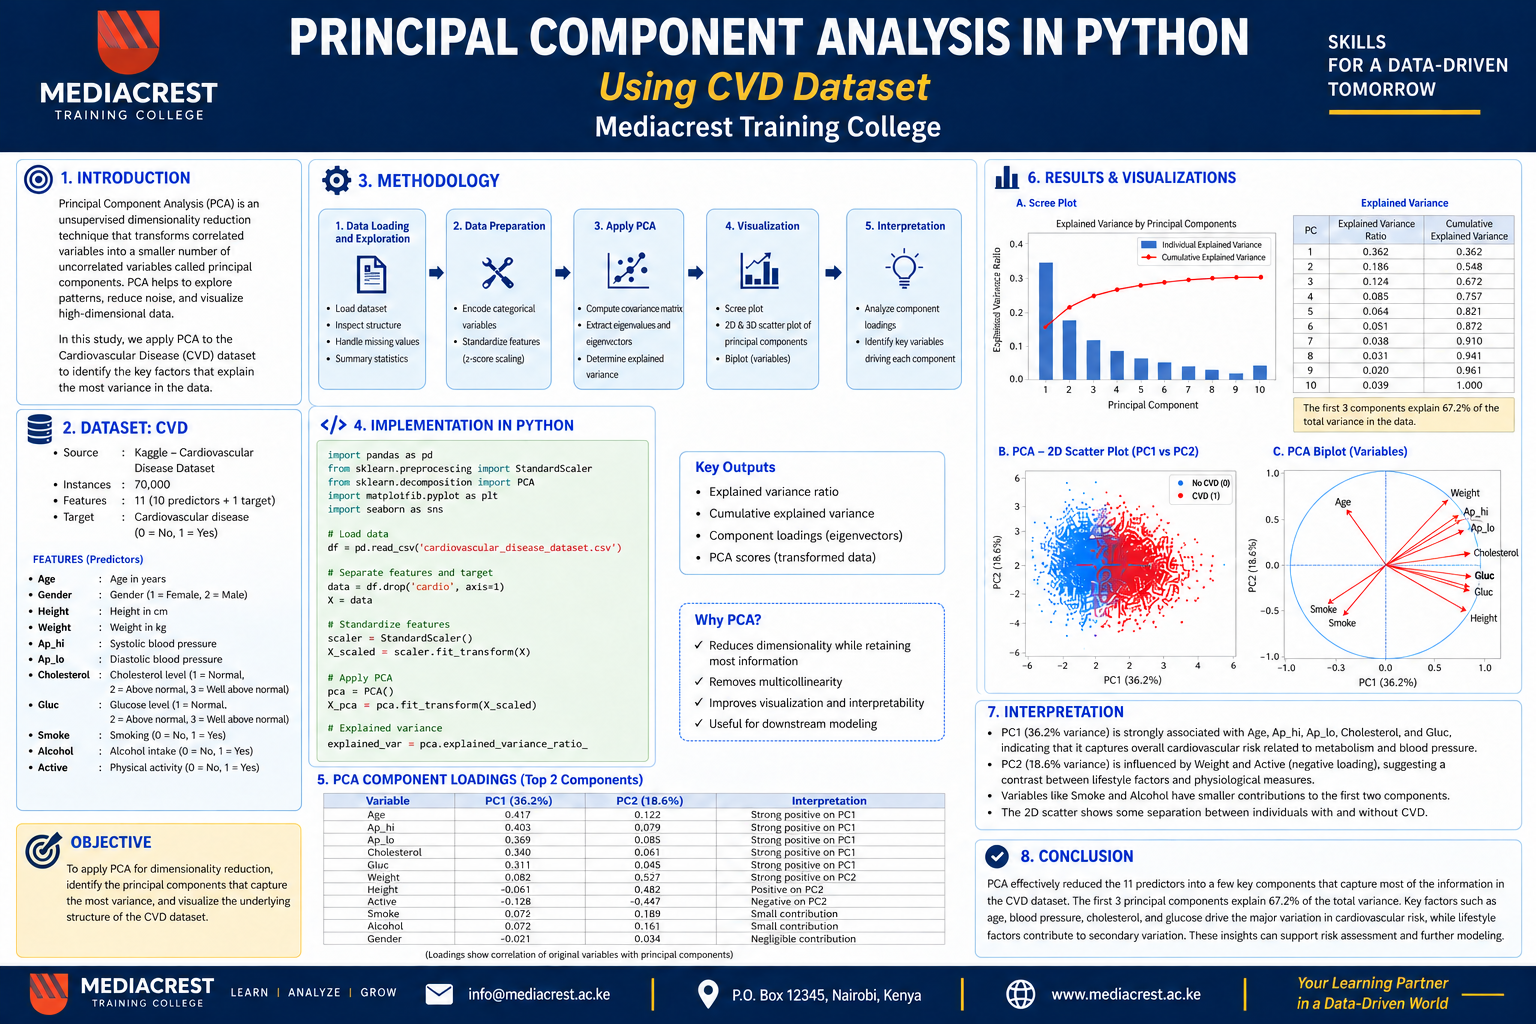

# **MEDIACREST TRAINING COLLEGE**
## **ADVANCE DATA ANALYSIS AND FUNDAMENTALS OF AI- WEEK 8**
### **Trainer: Lumumba W. Victor**|

## **UNSUPERVISED LEARNING - DIMENSIONALITY REDUCTION**

## **PRINCIPAL COMPONENT ANALYSIS (PCA)**

**Definition**

Principal Component Analysis (PCA) is a multivariate statistical technique used to reduce the dimensionality of a dataset while retaining as much information as possible. It transforms a large set of correlated variables into a smaller set of uncorrelated variables called **principal components**. PCA is widely used in data science, machine learning, bioinformatics, finance, healthcare, and social sciences for data exploration and visualization.

### **Objectives of PCA**

1. Reduce the number of variables in a dataset.
2. Remove multicollinearity among predictors.
3. Retain maximum variation present in the original data.
4. Simplify data interpretation and visualization.
5. Improve computational efficiency in predictive modeling.

### **How PCA Works**

PCA creates new variables known as principal components (PCs). These components are linear combinations of the original variables and are arranged according to the amount of variance they explain:

* **First Principal Component (PC1):** Captures the largest possible variance.
* **Second Principal Component (PC2):** Captures the second-largest variance and is orthogonal to PC1.
* Subsequent components explain progressively smaller amounts of variance.

The mathematical foundation of PCA is based on the decomposition of the covariance or correlation matrix through eigenvalues and eigenvectors.

### **Steps in PCA**

1. Standardize the data.
2. Compute the covariance/correlation matrix.
3. Calculate eigenvalues and eigenvectors.
4. Rank principal components by explained variance.
5. Select important components.
6. Transform the original data into the new component space.

### **Advantages of PCA**

* Reduces data complexity.
* Eliminates redundancy among variables.
* Facilitates visualization of high-dimensional data.
* Enhances machine learning model performance.

### **Limitations of PCA**

* Components may be difficult to interpret.
* Sensitive to scaling of variables.
* Assumes linear relationships among variables.

### **Conclusion**

PCA is a powerful unsupervised learning technique that summarizes large datasets into a few informative components while preserving most of the original variation. It serves as an essential tool for exploratory data analysis, feature extraction, and dimensionality reduction in modern statistical and machine learning applications.


### **Load the Needed Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

### **Read the Data**

In [2]:
df =pd.read_csv("CVD_risk.csv")
df.head()

,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,Fasting_Glucose,CRP_Inflammation,Age,LDL_Cholesterol,CVD_Risk
0,0.633624,0.972012,0.533317,-0.729261,0.579548,0.666505,47.892110,0.213374,1
1,-0.294739,-0.153430,-0.440258,-0.075292,-0.872730,-1.010284,68.620717,-0.234435,0
2,0.813915,0.470587,0.766758,-0.536103,1.622474,0.449300,45.093939,0.569784,1
3,1.990625,1.144601,1.831485,-0.688583,1.955860,0.842074,40.329073,1.713434,1
4,-0.266326,-0.684938,0.456672,0.275218,0.307085,0.358382,39.738682,0.094073,0


### **EXPLORATORY DATA ANALYSIS & CORRELATION CHECK**

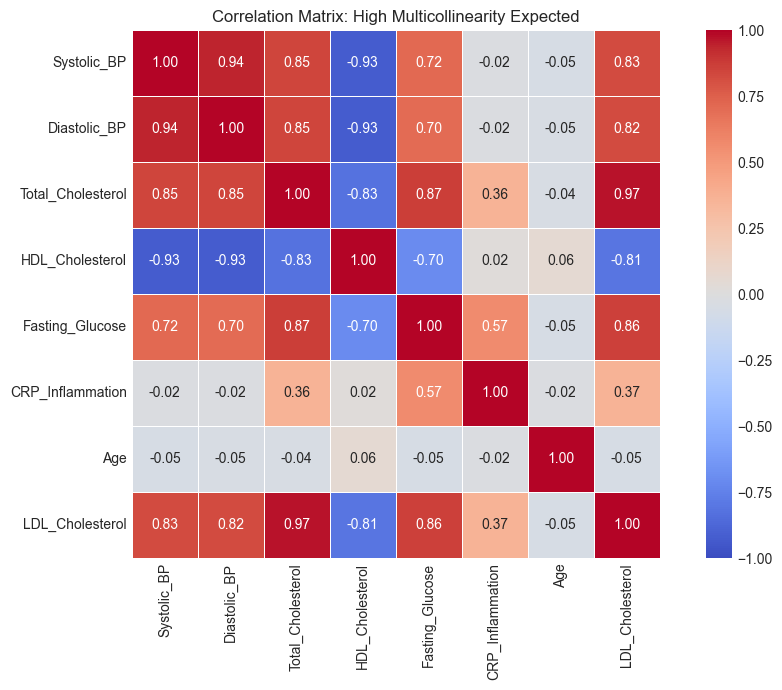

🔍 Observing high correlations (|r| > 0.7) among BP, Cholesterol, Glucose markers.
   PCA is ideal here to reduce redundancy and stabilize downstream models.



In [3]:
features = df.columns[:-1]
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix: High Multicollinearity Expected')
plt.tight_layout()
plt.show()

print("🔍 Observing high correlations (|r| > 0.7) among BP, Cholesterol, Glucose markers.")
print("   PCA is ideal here to reduce redundancy and stabilize downstream models.\n")

### **PREPROCESSING & TRAIN/TEST SPLIT**

In [4]:
X = df[features].values
y = df['CVD_Risk'].values

### **Split BEFORE scaling to prevent data leakage**
This line of code beloww is splitting a dataset into training and testing subsets using the function `train_test_split()` from the machine learning library (commonly scikit-learn). The goal is to prepare data for building and evaluating a predictive model.

The input variables `X` and `y` represent the dataset features (independent variables) and the target variable (dependent variable), respectively. The function divides these into two parts: one for training the model and one for testing its performance.

The parameter `test_size=0.25` means that 25% of the entire dataset is set aside as the test set, while the remaining 75% is used for training. This allows the model to learn patterns from most of the data and then be evaluated on unseen data to assess generalization performance.

The `random_state=42` ensures reproducibility. It fixes the randomness in the splitting process so that every time the code is run, the same train-test split is obtained. This is important for consistent results during experimentation and reporting.

The `stratify=y` argument ensures that the proportion of classes in the target variable `y` is preserved in both the training and testing sets. This is especially important in classification problems where the dataset may be imbalanced. By maintaining the same class distribution, the model evaluation becomes more reliable and representative of real-world performance.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y)

### **PCA is variance-sensitive → MUST standardize features**
This code performs feature standardization using the `StandardScaler` from scikit-learn, which is an important preprocessing step in many machine learning workflows.

First, `scaler = StandardScaler()` initializes the scaler object. This scaler will transform the data so that each feature has a mean of 0 and a standard deviation of 1.

Next, `X_train_scaled = scaler.fit_transform(X_train)` fits the scaler on the training data and transforms it at the same time. Fitting means it calculates the mean and standard deviation for each feature using only the training set, which prevents data leakage from the test set.

Then, `X_test_scaled = scaler.transform(X_test)` applies the same transformation to the test data using the parameters learned from the training data. This ensures consistency between training and testing distributions.

Finally, the print statement confirms that the data has been successfully split and standardized for model training.


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data split & standardized (mean=0, variance=1).")

✅ Data split & standardized (mean=0, variance=1).


### **PCA FITTING & COMPONENT SELECTION**
The code below is used to perform **Principal Component Analysis (PCA)** on the training dataset after it has been standardized. The objective is to identify how much variance each principal component explains before deciding how many components to retain for further analysis.

The first line creates a PCA object called `pca_full`. Since the number of components is not specified, PCA will compute **all possible principal components** from the dataset. The parameter `random_state=42` ensures reproducibility of results whenever randomness is involved.

The second line performs two operations simultaneously using the `fit_transform()` method. First, PCA is **fitted** to the standardized training data (`X_train_scaled`) by calculating the covariance structure of the variables and extracting the corresponding eigenvalues and eigenvectors. These eigenvectors define the directions of maximum variation in the data and become the principal components.

Second, the original standardized data is **transformed** into a new coordinate system defined by these principal components. The resulting matrix, `X_train_pca_full`, contains the scores of each observation on every principal component.

After fitting PCA on all components, researchers can examine attributes such as `explained_variance_ratio_` and cumulative explained variance to determine the optimal number of components to retain. This helps reduce dimensionality while preserving most of the information contained in the original variables, thereby improving visualization, reducing noise, and potentially enhancing machine learning model performance.


### **Fit PCA on ALL components first to evaluate variance explained**

In [7]:
pca_full = PCA(random_state=42)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)
X_train_pca_full

array([[-0.11683563, -0.1982702 , -1.06913629, ...,  0.09654622,
        -0.01602333,  0.14320592],
       [ 1.39323022, -0.85986402,  0.55693229, ..., -0.54397165,
        -0.12627057, -0.17458266],
       [-0.12997117, -1.20182854, -1.03769044, ...,  0.61223156,
        -0.18257655, -0.01671955],
       ...,
       [-1.79967132, -0.41756346, -0.43129631, ..., -0.49128527,
         0.27558756,  0.09867719],
       [ 3.30610714, -0.57918996,  0.78883259, ...,  0.30296626,
         0.14274974,  0.13856119],
       [ 0.74896062,  1.75537434,  0.67313443, ..., -0.05719792,
         0.08138515,  0.05337818]], shape=(450, 8))

### **Explained Variance**
This code extracts and summarizes how much variance is explained by each principal component in a Principal Component Analysis (PCA) model.

The variable `explained_var = pca_full.explained_variance_ratio_` returns an array showing the proportion of the dataset’s total variance captured by each principal component. Each value indicates how important that component is in representing the original data.

Next, `cumulative_var = np.cumsum(explained_var)` computes the cumulative sum of these variance ratios using NumPy. This produces an array where each element shows the total variance explained up to that component.

Together, these metrics help decide how many principal components to retain while reducing dimensionality effectively.


In [8]:
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

In [9]:
cumulative_var

array([0.66205573, 0.82869684, 0.95236658, 0.9700104 , 0.98129349,
       0.99018687, 0.99715653, 1.        ])

### **Determine optimal components (e.g., 90% variance threshold)**
This code determines the optimal number of principal components to retain in PCA based on a chosen explained variance threshold.

First, `threshold = 0.90` sets the target level of total variance to be retained, meaning the goal is to preserve 90% of the information in the dataset.

Then, `n_components_opt = np.argmax(cumulative_var >= threshold) + 1` finds the first index where the cumulative explained variance reaches or exceeds 0.90. The `np.argmax()` function returns the position of the first True condition, and adding 1 adjusts for Python’s zero-based indexing. This gives the minimum number of components needed to reach the desired variance level.

Finally, the print statements display the explained variance for each component, the cumulative variance, and the optimal number of components. This helps in making an informed decision about dimensionality reduction while preserving most of the dataset’s information.


In [10]:
threshold = 0.90
n_components_opt = np.argmax(cumulative_var >= threshold) + 1

print(f"📊 Explained Variance per Component: {np.round(explained_var, 3)}")
print(f"📈 Cumulative Variance: {np.round(cumulative_var, 3)}")
print(f"🎯 Optimal Components for {threshold*100}% Variance: {n_components_opt}\n")

📊 Explained Variance per Component: [0.662 0.167 0.124 0.018 0.011 0.009 0.007 0.003]
📈 Cumulative Variance: [0.662 0.829 0.952 0.97  0.981 0.99  0.997 1.   ]
🎯 Optimal Components for 90.0% Variance: 3



### **VISUALIZATION**
This code visualizes the results of Principal Component Analysis (PCA) using two side-by-side plots to help interpret dimensionality reduction.

First, `fig, axes = plt.subplots(1, 2, figsize=(14, 5))` creates a figure with one row and two columns of subplots.

On the left, a Scree Plot is generated. The line `axes[0].plot(range(1, len(explained_var)+1), explained_var, 'bo-')` shows the variance explained by each individual principal component. Another line plots the cumulative explained variance (`cumulative_var`) in red. A horizontal green dashed line represents the selected variance threshold (e.g., 90%), while a vertical purple line marks the optimal number of components (`n_components_opt`). Labels, title, legend, and grid are added for clarity.

On the right, a 2D PCA projection is created using the first two principal components: `PCA(n_components=2)`. The transformed training data is plotted as a scatter plot, where points are colored based on the target variable `y_train` (e.g., cardiovascular disease risk). This helps visualize class separation in reduced dimensions.

Finally, `plt.tight_layout()` adjusts spacing for readability, and `plt.show()` displays both plots together.


### **COMPONENT INTERPRETATION (LOADINGS)**

In [11]:
# Final PCA with optimal components
pca_opt = PCA(n_components=n_components_opt, random_state=42)
X_train_pca = pca_opt.fit_transform(X_train_scaled)
X_train_pca

array([[-0.11683563, -0.1982702 , -1.06913629],
       [ 1.39323022, -0.85986402,  0.55693229],
       [-0.12997117, -1.20182854, -1.03769044],
       ...,
       [-1.79967132, -0.41756346, -0.43129631],
       [ 3.30610714, -0.57918996,  0.78883259],
       [ 0.74896062,  1.75537434,  0.67313443]], shape=(450, 3))

In [12]:
X_test_pca = pca_opt.transform(X_test_scaled)
X_test_pca[:20]

array([[ 3.50731183, -0.44336942,  0.35738219],
       [ 0.05964431, -1.11073774,  0.43475438],
       [ 4.88145217,  1.03488993, -0.2760924 ],
       [ 5.15344968, -1.23066368, -0.4012044 ],
       [-2.58782076, -1.62369802,  1.42345819],
       [-4.55769608, -0.40346436,  0.50082036],
       [ 0.96194378,  0.0502663 ,  0.82571973],
       [-2.23939154,  0.12793142,  0.15186213],
       [ 1.90862566, -2.06560391, -0.85070363],
       [-2.08690331, -0.22849491,  0.10427585],
       [-3.70065367, -0.99185097,  1.2912706 ],
       [-1.42888745, -1.91503824, -0.65136306],
       [-2.64818373,  0.20733298, -0.95789233],
       [-2.73659844,  0.30405248, -1.60531547],
       [ 0.62932683, -0.03040546, -0.40593994],
       [-1.11446639,  1.245758  , -1.16790702],
       [-0.03220153,  0.31825378, -0.60104603],
       [-1.95771691,  0.46717988, -0.9726929 ],
       [-0.83380525, -1.2714864 ,  0.19493859],
       [-0.40279958, -1.61931506, -1.37926557]])

### **Components Loading**
This code computes and displays the PCA loadings, which describe how much each original feature contributes to each principal component in the reduced dataset.

First, `pca_opt.components_` contains the principal axes learned by the PCA model. Each row represents a principal component, and each column corresponds to a feature. The `.T` (transpose) is applied so that features become rows and components become columns, making the table easier to interpret in a feature-by-feature format.

Next, a pandas DataFrame called `loadings` is created. The columns are named dynamically as `PC1`, `PC2`, … up to the optimal number of components (`n_components_opt`). The index is set to `features`, which contains the original variable names (e.g., clinical or demographic variables).

The statement `print(loadings.round(3))` displays the loadings rounded to three decimal places for readability. These values indicate the strength and direction of each feature’s influence on a given principal component.

Finally, the printed interpretation notes explain that large absolute values (positive or negative) indicate that a feature strongly contributes to that component. This helps in understanding what each principal component represents conceptually, such as grouping related clinical variables together, and allows for meaningful interpretation of reduced-dimensional features in a machine learning context.


In [13]:
loadings = pd.DataFrame(
    pca_opt.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_opt)],
    index=features
)

print("📐 Component Loadings (Feature Weights in Each PC)")
print(loadings.round(3))
print("\n💡 Interpretation Tip: High absolute loading = feature strongly drives that PC.")
print("   You can rotate loadings to see which clinical constructs each PC represents.\n")

📐 Component Loadings (Feature Weights in Each PC)
                     PC1    PC2    PC3
Systolic_BP        0.403 -0.257  0.040
Diastolic_BP       0.403 -0.257  0.055
Total_Cholesterol  0.421  0.109  0.014
HDL_Cholesterol   -0.396  0.275 -0.027
Fasting_Glucose    0.387  0.316 -0.003
CRP_Inflammation   0.128  0.812 -0.070
Age               -0.044  0.089  0.995
LDL_Cholesterol    0.416  0.116 -0.002

💡 Interpretation Tip: High absolute loading = feature strongly drives that PC.
   You can rotate loadings to see which clinical constructs each PC represents.



This output shows the **PCA component loadings**, which explain how each original clinical feature contributes to the principal components (PCs). These loadings are essentially weights that indicate the strength and direction of influence of each variable in forming a component.

For **PC1**, the largest positive loadings come from Total Cholesterol (0.421), LDL Cholesterol (0.416), Systolic BP (0.403), Diastolic BP (0.403), and Fasting Glucose (0.387). HDL Cholesterol has a strong negative loading (-0.396). This suggests that PC1 represents a general **cardiometabolic risk factor axis**, where higher values correspond to worse cardiovascular risk profiles (higher blood pressure, cholesterol, and glucose, and lower protective HDL levels).

For **PC2**, the dominant feature is CRP Inflammation (0.812), indicating that this component mainly captures **systemic inflammation**. Moderate contributions from Fasting Glucose (0.316) and HDL Cholesterol (0.275) suggest a secondary relationship between metabolic dysregulation and inflammation. Blood pressure and LDL have smaller negative or weak effects here, meaning they are less influential in this component.

For **PC3**, Age has an extremely high loading (0.995), meaning this component is almost entirely driven by age. This suggests PC3 represents a **pure age-related dimension**, largely independent of biochemical markers.

The interpretation tip emphasizes that high absolute values (whether positive or negative) indicate strong influence. The sign only indicates direction, not importance. For example, HDL being negative in PC1 suggests it moves opposite to risk factors.

Overall, PCA has successfully reduced the dataset into interpretable hidden structures:
PC1 = cardiovascular/metabolic risk,
PC2 = inflammation-related variation,
PC3 = age-driven variation.

This transformation is useful for simplifying models, reducing multicollinearity, and improving machine learning performance while retaining meaningful clinical patterns.


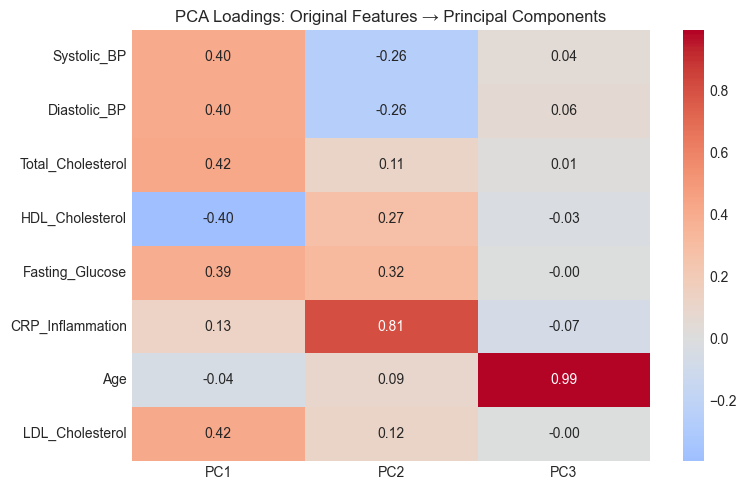

In [14]:
# Loading Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('PCA Loadings: Original Features → Principal Components')
plt.tight_layout()
plt.show()

### **MODEL EVALUATION: RAW vs PCA-TRANSFORMED FEATURES")**

### **A. Logistic Regression (Raw Scaled Features)**
This code is part of a model evaluation workflow where Logistic Regression is trained using the **original scaled features (raw feature space)**, before applying PCA transformation.

First, the line `model_raw = LogisticRegression(max_iter=1000, random_state=42)` initializes a Logistic Regression classifier. The parameter `max_iter=1000` increases the maximum number of iterations allowed for the optimization algorithm (used to find the best-fitting coefficients), ensuring convergence even for complex datasets. The `random_state=42` ensures reproducibility of results.

Next, `model_raw.fit(X_train_scaled, y_train)` trains the model using the standardized training data (`X_train_scaled`) and the corresponding target labels (`y_train`). During this step, the model learns relationships between the original features (such as blood pressure, cholesterol, glucose, and age) and the outcome variable (e.g., disease presence or risk category).

This baseline model is important because it provides a reference performance level before dimensionality reduction. Later, its accuracy, precision, recall, and other metrics can be compared with a PCA-based model to evaluate whether PCA improves performance, reduces overfitting, or enhances computational efficiency.


#### **Initializing the Model Fitting Process**

In [ ]:
model_raw = LogisticRegression(max_iter=1000, random_state=42)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### **Fit model**

In [16]:
model_raw.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### **Predictions**
This code evaluates the performance of the Logistic Regression model trained on **raw scaled features** by generating predictions and performing cross-validation.

First, `y_pred_raw = model_raw.predict(X_test_scaled)` produces the predicted class labels (e.g., 0 or 1) for the test dataset based on learned decision boundaries. These predictions are used for calculating classification metrics such as accuracy, precision, recall, and F1-score.

Next, `y_prob_raw = model_raw.predict_proba(X_test_scaled)[:, 1]` computes the predicted probabilities for the positive class (class 1). The `predict_proba()` function returns probabilities for all classes, and selecting `[:, 1]` extracts the likelihood of the positive outcome, which is useful for ROC curve analysis and AUC computation.

Then, cross-validation is performed using `cross_val_score()`. The first call computes **mean accuracy** across 5 folds (`cv=5`), giving a more robust estimate of model performance. The second computes **mean ROC-AUC**, which evaluates the model’s ability to distinguish between classes across different thresholds. These results help assess generalization and model stability.


In [17]:
y_pred_raw = model_raw.predict(X_test_scaled)
y_prob_raw = model_raw.predict_proba(X_test_scaled)[:, 1]

# Cross-validation
cv_acc_raw = cross_val_score(model_raw, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
cv_auc_raw = cross_val_score(model_raw, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()

### **Print results**

In [18]:
print("\n🔹 Logistic Regression (Raw Scaled Features)")
print(f"   Test Accuracy: {accuracy_score(y_test, y_pred_raw):.4f}")
print(f"   Test ROC-AUC : {roc_auc_score(y_test, y_prob_raw):.4f}")
print(f"   CV Accuracy  : {cv_acc_raw:.4f}")
print(f"   CV ROC-AUC   : {cv_auc_raw:.4f}")
print(classification_report(y_test, y_pred_raw, target_names=['Low Risk', 'High Risk']))



🔹 Logistic Regression (Raw Scaled Features)
   Test Accuracy: 0.8400
   Test ROC-AUC : 0.9252
   CV Accuracy  : 0.8600
   CV ROC-AUC   : 0.9452
              precision    recall  f1-score   support

    Low Risk       0.85      0.83      0.84        75
   High Risk       0.83      0.85      0.84        75

    accuracy                           0.84       150
   macro avg       0.84      0.84      0.84       150
weighted avg       0.84      0.84      0.84       150



### **B. Logistic Regression (PCA Features)**
This code trains a Logistic Regression model using PCA-transformed features, allowing comparison with the model trained on the original scaled dataset.

First, model_pca = LogisticRegression(max_iter=1000, random_state=42) initializes the Logistic Regression classifier. The parameter max_iter=1000 increases the number of iterations allowed for the optimization algorithm (such as LBFGS or SAG) to ensure convergence, especially when working with transformed feature spaces. The random_state=42 ensures that results are reproducible across different runs.

Next, model_pca.fit(X_train_pca, y_train) trains the model using the principal component scores (X_train_pca) instead of the original features. These PCA features are linear combinations of the original variables and are designed to capture most of the variance in fewer dimensions while reducing multicollinearity and noise.

This step is important because it allows evaluation of whether dimensionality reduction improves model performance. The PCA-based model may train faster, generalize better, or reduce overfitting, especially when the original dataset has correlated or redundant features. It also provides a simpler representation of the underlying data structure for classification.

In [19]:
# Initialzie Logistic Model Training Process
model_pca = LogisticRegression(max_iter=1000, random_state=42)

# Fit model
model_pca.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### **Predictions**

In [20]:
y_pred_pca = model_pca.predict(X_test_pca)
y_prob_pca = model_pca.predict_proba(X_test_pca)[:, 1]

# Cross-validation
cv_acc_pca = cross_val_score(model_pca, X_train_pca, y_train, cv=5, scoring='accuracy').mean()
cv_auc_pca = cross_val_score(model_pca, X_train_pca, y_train, cv=5, scoring='roc_auc').mean()

#### **Print the Results**

In [21]:
print(f"\n🔹 Logistic Regression ({n_components_opt} PCA Components)")
print(f"   Test Accuracy: {accuracy_score(y_test, y_pred_pca):.4f}")
print(f"   Test ROC-AUC : {roc_auc_score(y_test, y_prob_pca):.4f}")
print(f"   CV Accuracy  : {cv_acc_pca:.4f}")
print(f"   CV ROC-AUC   : {cv_auc_pca:.4f}")
print(classification_report(y_test, y_pred_pca, target_names=['Low Risk', 'High Risk']))


🔹 Logistic Regression (3 PCA Components)
   Test Accuracy: 0.8533
   Test ROC-AUC : 0.9200
   CV Accuracy  : 0.8467
   CV ROC-AUC   : 0.9302
              precision    recall  f1-score   support

    Low Risk       0.87      0.83      0.85        75
   High Risk       0.84      0.88      0.86        75

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



### **CONCLUSION AND COMPARISON**
This section compares the performance of a **Logistic Regression model trained on raw scaled features** versus one trained on **PCA-reduced features (3 principal components)**.

For the **raw scaled model**, the test accuracy is **0.8400**, meaning 84% of the test samples are correctly classified. The ROC-AUC score of **0.9252** indicates strong discriminatory ability between Low Risk and High Risk classes. Cross-validation results are slightly higher (Accuracy = **0.8600**, ROC-AUC = **0.9452**), showing that the model is relatively stable and generalizes well across different folds.

The classification report shows balanced performance across both classes. For Low Risk, precision is 0.85 and recall is 0.83, while for High Risk, precision is 0.83 and recall is 0.85. This symmetry suggests the model is not biased toward one class, which is important given equal class support (75 observations each).

For the **PCA-based model (3 components)**, performance improves slightly in accuracy to **0.8533**, indicating better generalization after dimensionality reduction. However, ROC-AUC slightly decreases to **0.9200**, suggesting a minor reduction in ranking performance. Cross-validation accuracy is **0.8467**, and CV ROC-AUC is **0.9302**, both still strong and comparable to the raw model.

The classification report shows improved recall for High Risk (0.88), meaning the PCA model is better at identifying high-risk individuals, which is often more important in healthcare applications. Precision remains strong (0.84–0.87 range), and overall F1-scores improve slightly to around 0.85–0.86.

Overall, the comparison shows that PCA reduces dimensionality from multiple correlated clinical variables into 3 components while maintaining or slightly improving predictive performance. The PCA model is more compact, computationally efficient, and still clinically meaningful. It demonstrates that most predictive information is captured in a few underlying structures (risk, inflammation, and age), making PCA a useful preprocessing step for simplified yet effective medical prediction models.


## **THE END**